# Multimodal Pain Assessment from EEG and Wristband Physiological Signals

**Team:**
* Jonathan Miller
* Meng Li
* Raj Mamidala

**Course:** AI 570 §002, Deep Learning (Summer 2026)

### Problem Statement

Pain is normally measured by asking, which fails exactly when it matters most: infants, sedated or intubated patients, people with advanced dementia. Pain also has physiological consequences that sensors can pick up, so an objective estimate from wearables is at least plausible

This project asks a narrow version of that question: how much pain signal survives when the sensors are cheap consumer devices, the test participants are strangers to the model, and the evaluation is done carefully. We classify self-reported pain type (none, headache, back pain, menstrual pain) from a single-electrode EEG headband and a wristband, compare single-modality models against a dual-branch fusion network, and measure two things that usually go unmeasured: what a leaked train/test split is worth, and how much of our signal is a sex confound rather than pain

* **Keywords:** pain assessment, physiological signals, EEG, multimodal fusion, time-series classification, data leakage

### Data Collection

* **Source (url):** https://www.kaggle.com/datasets/orvile/physiopain-dataset
  (Mendeley DOI `10.17632/mf2cgph9cy.4`, CC BY 4.0, Istanbul Kültür Üniversitesi)
* **Short description:** PhysioPain, single-channel EEG band powers (NeuroSky MindWave Mobile 2) at 1 Hz plus Empatica E4 wristband signals (BVP, EDA, temperature, accelerometer), with survey responses including the McGill Pain Questionnaire. 83 subjects usable in the raw EEG tier.
* **Keywords:** EEG, electrodermal activity, wearables, pain

_See `docs/dataset-notes.md` for the full data audit._

### Required packages

On Kaggle, attach `orvile/physiopain-dataset` and run the install cell below.
Locally: `pip install -e ".[local]"` then `python scripts/get_data.py`.

In [1]:
# --- setup -------------------------------------------------------------------
# On Kaggle, uncomment to pull the package from our private repo:
# from kaggle_secrets import UserSecretsClient
# tok = UserSecretsClient().get_secret("GH_TOKEN")
# !pip install -q git+https://{tok}@github.com/RM-28/multimodal-pain-assesment.git

import os, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # hush the oneDNN chatter
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from painnet import config, data, windows, splits, models, evaluate, plots

plots.use_style()
print(config.describe())


painnet | env=local | data=found | /Users/jmill/coding/github/psuai570/project/multimodal-pain-assesment/data/raw/PhysioPain Dataset/Multimodal Pain Dataset


### Data Preprocessing

We audited the archive before modelling, and the audit changed what we trained on. Full detail lives in `docs/dataset-notes.md`; the short version:

1. **Use the raw 1 Hz EEG tier, not the processed one.** The processed tier lists participants with comorbid pain under 2-3 label folders with byte-identical signals, so about a quarter of its rows carry more than one label. The raw tier is disjoint: 83 files, 83 people, one label each
2. **Drop two dead columns.** `Derived` is 100% empty and `totPwr` is exactly the sum of the eight band powers
3. **Drop row 0 of every wristband file.** The Empatica writes its sample rate on line two of its raw files and the dataset authors' conversion kept it, so the first "measurement" in every processed watch file says the skin temperature was 4 degrees
4. **Z-score per participant.** Raw band powers span four orders of magnitude and mostly encode how well the headset was seated
5. **Window.** 60 s windows, 15 s stride, windows never cross a participant boundary

The cell below runs steps 1-5 and prints what came out. One check matters more than the rest: every participant has exactly one pain label for their whole recording, which we verify rather than assume, because the entire evaluation design follows from it

In [2]:
# load, clean, window. all the logic lives in src/painnet so the other
# notebooks and the scripts use exactly the same code path
df = data.load_raw_eeg()

# the fact the whole design rests on: one label per person. verify, don't trust
labels_per_person = df.groupby(config.SUBJECT_COL)[config.LABEL_COL].nunique()
assert (labels_per_person == 1).all(), "a participant has >1 label?!"
print(f"{labels_per_person.size} participants, every one with a single pain label")

X, y, groups = windows.build_dataset()
y_int = windows.encode_labels(y)
print(f"windows: {X.shape}  (n, 60 s at 1 Hz, 10 channels)")

# class balance counted in PEOPLE, since people are the real sample size
subj = df.groupby(config.SUBJECT_COL)[config.LABEL_COL].first()
print("\nparticipants per class:")
print(subj.value_counts().to_string())
print(f"\nmajority-class share: {subj.value_counts(normalize=True).max():.3f}"
      "  <- that's the trivial model's ACCURACY, not its macro-F1")

83 participants, every one with a single pain label


windows: (6465, 60, 10)  (n, 60 s at 1 Hz, 10 channels)

participants per class:
pain_type
headache          30
back_pain         28
no_pain           15
menstrual_pain    10

majority-class share: 0.361  <- that's the trivial model's ACCURACY, not its macro-F1


### Methodology

**The split is the core design decision.** Because each participant carries one label, a window inherits its label from the person it came from. Split windows randomly and near-identical overlapping slices of one recording land on both sides, so the model succeeds by recognising people. All cross-validation here is `StratifiedGroupKFold` grouped on participant, stratified so the 10 menstrual-pain participants spread across folds. The splitter asserts train/test disjointness on every fold and raises if it ever fails, and that guard has its own tests (`pytest`, ~2 s)

We do not just assert this matters. A controlled experiment further down measures what a leaked split is worth on this exact data

**Models, smallest first.** With 83 people, extra capacity buys memorisation, so everything is deliberately small

* **1D CNN** (14.5k params): local waveform structure, our baseline
* **CNN-LSTM** (28.7k): conv features into a recurrent layer
* **TCN** (71k): dilated causal convolutions, receptive field spans the whole 60 s window
* **Dual-branch fusion** (26k): one encoder per modality at its native rate (EEG 1 Hz, wristband 4 Hz), concatenated embeddings, shared head. This is why the project needs the Keras Functional API, two inputs at two sample rates do not fit `Sequential`
* **LightGBM control**: a gradient-boosted tree on 40 summary stats per window, no time series at all. If it keeps up with the nets, the temporal structure is not carrying much at this sample size

**Metrics.** Macro-F1 leads because the smallest class is 12% of participants. Everything is reported mean ± std over 5 folds; with ~17 test participants per fold, a single split is noise. And we measure the trivial floor per fold instead of deriving it, having learned that lesson the hard way (we quoted the wrong bar for a week: 0.361 is the majority model's accuracy, its macro-F1 is 0.132)

* **Keywords:** supervised learning, multi-class classification, grouped cross-validation, multimodal fusion

### Model Fitting and Validation

Same treatment for every model: seed reset before each build so comparisons are fair, class-weighted loss so the rare classes cannot be ignored, Adam 1e-3, early stopping on validation loss (patience 8). Everything converges in 9-17 epochs

The loop below is the real evaluation, 5 subject-wise folds for each of the four models plus the majority-class floor. It takes about 4 minutes on a laptop CPU. Training chatter is silenced (`verbose=0`) so the per-fold summary lines stay readable

In [3]:
# the full comparison: majority floor, lightgbm control, three nets.
# identical protocol to scripts/run_baselines.py, condensed for the notebook
import lightgbm as lgb

def lgbm():
    return lgb.LGBMClassifier(
        objective="multiclass", num_class=len(config.PAIN_CLASSES),
        n_estimators=300, learning_rate=0.05, num_leaves=15,
        min_child_samples=40, subsample=0.8, subsample_freq=1,
        colsample_bytree=0.8, random_state=config.SEED, verbose=-1)

X_tab = windows.to_tabular(X)          # mean/std/min/max per channel, for the tree
rows = []
oof_tcn = np.full(len(y_int), -1)      # out-of-fold preds so we can draw one
                                       # confusion matrix over everybody

for k, (tr, te) in enumerate(splits.subject_folds(groups, y_int)):
    w = windows.class_weights(y_int[tr])

    # trivial floor, measured not derived
    maj = np.bincount(y_int[tr]).argmax()
    rows.append({"model": "majority", "fold": k,
                 **evaluate.fold_metrics(y_int[te], np.full(len(te), maj))})

    # the tree control
    clf = lgbm()
    clf.fit(X_tab[tr], y_int[tr], sample_weight=[w[c] for c in y_int[tr]])
    rows.append({"model": "lightgbm", "fold": k,
                 **evaluate.fold_metrics(y_int[te], clf.predict(X_tab[te]))})

    # the three nets
    for name, build in models.BUILDERS.items():
        m = models.compile_model(build(X.shape[1:]))
        m.fit(X[tr], y_int[tr], validation_split=0.15,
              epochs=60, batch_size=64, verbose=0,
              class_weight=w, callbacks=models.default_callbacks())
        pred = m.predict(X[te], verbose=0).argmax(1)
        rows.append({"model": name, "fold": k,
                     **evaluate.fold_metrics(y_int[te], pred),
                     **evaluate.per_class_f1(y_int[te], pred)})
        if name == "tcn":
            oof_tcn[te] = pred
    print(f"fold {k}: " + "  ".join(
        f"{r['model']}={r['macro_f1']:.3f}" for r in rows[-5:]))

folds_df = pd.DataFrame(rows)
print("\ndone,", len(folds_df), "model-fold results")

fold 0: majority=0.136  lightgbm=0.172  cnn1d=0.256  cnn_lstm=0.179  tcn=0.258


fold 1: majority=0.134  lightgbm=0.114  cnn1d=0.233  cnn_lstm=0.174  tcn=0.242


fold 2: majority=0.129  lightgbm=0.310  cnn1d=0.238  cnn_lstm=0.227  tcn=0.265


fold 3: majority=0.130  lightgbm=0.225  cnn1d=0.268  cnn_lstm=0.256  tcn=0.277


fold 4: majority=0.132  lightgbm=0.355  cnn1d=0.110  cnn_lstm=0.162  tcn=0.161

done, 25 model-fold results


### Model Evaluation

Read the table below with the floor in mind: the always-predict-headache model scores **0.132** macro-F1 (it gets 0.360 accuracy, which is why accuracy is the wrong headline here)

What to look for

* the TCN leads, but LightGBM ties it on the mean with about twice the fold spread. The deep model's real advantage is stability, not a higher average
* nothing beats the majority model on raw accuracy. That is the class weighting doing its job, trading accuracy for coverage of the rare classes
* the fold column matters more than the mean column. Same model, same data, and macro-F1 can move 3x between folds of 17 people

macro-F1, 5 subject-wise folds:
model
tcn         0.240 ± 0.046
lightgbm    0.235 ± 0.098
cnn1d       0.221 ± 0.064
cnn_lstm    0.199 ± 0.040
majority    0.132 ± 0.003


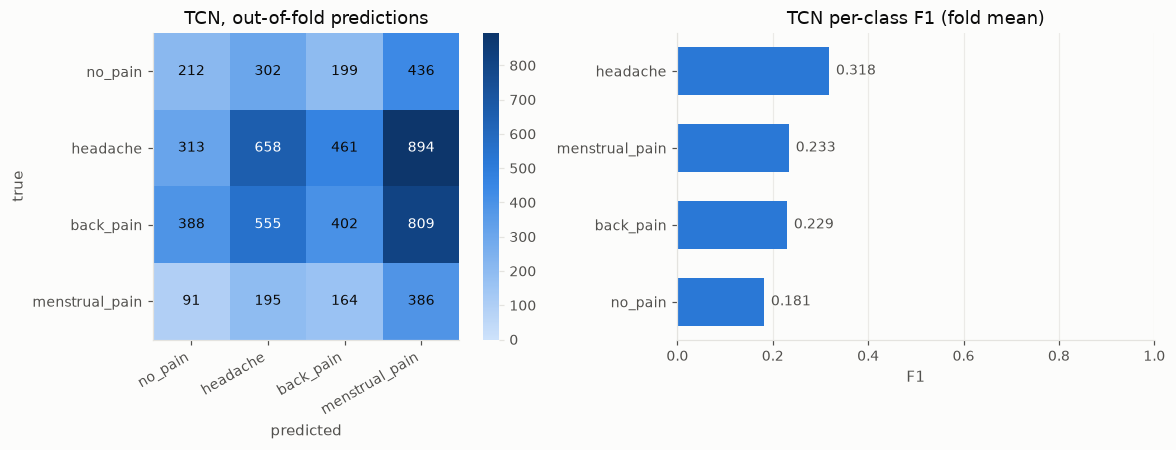

In [4]:
# mean ± std over folds, the only honest summary at this sample size
summary = (folds_df.groupby("model")["macro_f1"]
           .agg(["mean", "std"])
           .sort_values("mean", ascending=False))
summary["report"] = summary.apply(lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1)
print("macro-F1, 5 subject-wise folds:")
print(summary["report"].to_string())

# one confusion matrix over the out-of-fold TCN predictions, so every
# participant appears exactly once as a test subject
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
plots.confusion_matrix(evaluate.confusion(y_int, oof_tcn),
                       title="TCN, out-of-fold predictions", ax=axes[0])
tcn_f1 = {c: folds_df[folds_df.model == "tcn"][f"f1_{c}"].mean()
          for c in config.PAIN_CLASSES}
plots.per_class_f1(tcn_f1, title="TCN per-class F1 (fold mean)", ax=axes[1])
fig.tight_layout()
plt.show()

### What a leaked split is worth, measured

The methodology section claims a random window split produces a meaningless score. Cheap claim, so here is the experiment: same TCN, same hyperparameters, same 80/20 ratio, and the only variable is whether the split respects participant boundaries

Takes about 3 minutes

In [5]:
# same-model, split-only experiment. mirrors scripts/run_leakage_demo.py
import keras
def train_eval(Xtr, ytr, Xte, yte):
    keras.backend.clear_session()
    keras.utils.set_random_seed(config.SEED)
    m = models.compile_model(models.build_tcn(Xtr.shape[1:]))
    m.fit(Xtr, ytr, validation_split=0.15, epochs=60, batch_size=64, verbose=0,
          class_weight=windows.class_weights(ytr),
          callbacks=models.default_callbacks())
    return evaluate.fold_metrics(yte, m.predict(Xte, verbose=0).argmax(1))

# the leak: shuffle windows, ignore who they came from
rng = np.random.default_rng(config.SEED)
perm = rng.permutation(len(y_int)); cut = int(0.8 * len(perm))
tr_bad, te_bad = perm[:cut], perm[cut:]
shared = len(set(groups[tr_bad]) & set(groups[te_bad]))
print(f"random window split: {shared} of {len(set(groups))} participants on BOTH sides")
leaked = train_eval(X[tr_bad], y_int[tr_bad], X[te_bad], y_int[te_bad])

# the fix: participants stay whole (fold 0 of the same splitter as above)
tr_ok, te_ok = next(iter(splits.subject_folds(groups, y_int)))
honest_split = train_eval(X[tr_ok], y_int[tr_ok], X[te_ok], y_int[te_ok])

print(f"\n{'':22s}{'accuracy':>10s}{'macro-F1':>10s}")
print(f"{'leaked (random)':22s}{leaked['accuracy']:>10.3f}{leaked['macro_f1']:>10.3f}")
print(f"{'grouped by person':22s}{honest_split['accuracy']:>10.3f}{honest_split['macro_f1']:>10.3f}")
print(f"\ninflation on macro-F1: {leaked['macro_f1']/honest_split['macro_f1']:.1f}x")

random window split: 83 of 83 participants on BOTH sides



                        accuracy  macro-F1
leaked (random)            0.896     0.899
grouped by person          0.253     0.258

inflation on macro-F1: 3.5x


### Saved model

The submission includes the trained TCN. The cell below saves it, reloads it from disk, and checks the reloaded copy makes identical predictions, so the file in `models/final/` is known-good rather than assumed-good

In [6]:
# train the final TCN on the best fold's split and save it
best_fold = folds_df[folds_df.model == "tcn"].macro_f1.idxmax()
k_best = int(folds_df.loc[best_fold, "fold"])
fold_iter = splits.subject_folds(groups, y_int)
for _ in range(k_best + 1):
    tr, te = next(fold_iter)

m = models.compile_model(models.build_tcn(X.shape[1:]))
m.fit(X[tr], y_int[tr], validation_split=0.15, epochs=60, batch_size=64,
      verbose=0, class_weight=windows.class_weights(y_int[tr]),
      callbacks=models.default_callbacks())

config.ensure_dirs()
path = config.MODELS_DIR / "final" / "tcn_final.keras"
path.parent.mkdir(parents=True, exist_ok=True)
m.save(path)

# round-trip check: does the file on disk behave like the model in memory?
m2 = keras.models.load_model(path)
same = np.array_equal(m.predict(X[te], verbose=0).argmax(1),
                      m2.predict(X[te], verbose=0).argmax(1))
print(f"saved {path.name} ({path.stat().st_size/1e3:.0f} KB), reload matches: {same}")
print(f"held-out macro-F1 of this model: "
      f"{evaluate.fold_metrics(y_int[te], m2.predict(X[te], verbose=0).argmax(1))['macro_f1']:.3f}")

saved tcn_final.keras (948 KB), reload matches: True


held-out macro-F1 of this model: 0.277


### Multimodal fusion and the sex confound

The wristband and fusion experiments need the 4.9 GB watch tier, so this notebook loads their committed per-fold results rather than re-running them (regenerate with `scripts/run_fusion_repro.py` and `scripts/run_sex_probe.py` after `python scripts/get_data.py --watch`). The full protocol lives in `notebooks/fusion.ipynb`: nested splits with train, validation and test participants all disjoint, on the 77 people who wore both devices

Two results matter

1. **Fusion did not beat the best single modality.** Our proposal predicted it would. The wristband alone wins, and per-class the three approaches split the honours, so the modalities do carry different information, just not enough EEG signal to lift the pair above the wristband
2. **Sex is easier to decode than pain from the same windows.** All 10 menstrual-pain participants are female, so we trained the same models against a sex target as a control. From the same EEG windows, the lift over each task's own floor is +0.348 for sex versus +0.095 for pain, so every menstrual-pain score carries that caveat. With 10 participants we cannot remove the confound, but we can measure it, which is what this does

One provenance note: the fold tables loaded here are our independent rerun of the comparison. Meng's `fusion.ipynb` is the primary result (same ranking, means a little lower); the gap between the two runs comes from different scikit-learn builds dealing different fold assignments at the same seed, which is itself a good argument for the mean ± std discipline

In [7]:
# committed fold tables from the two big experiments
fus = pd.read_csv(config.REPO_ROOT / "results" / "fusion_repro_folds.csv")
sex = pd.read_csv(config.REPO_ROOT / "results" / "sex_probe_folds.csv")

print("modality comparison, 77 paired participants (macro-F1, 5 folds):")
t = fus.groupby("model")["macro_f1"].agg(["mean", "std"]).sort_values("mean", ascending=False)
for name, r in t.iterrows():
    print(f"  {name:16s} {r['mean']:.3f} ± {r['std']:.3f}")

print("\nsame models, same folds, sex target instead of pain (macro-F1):")
for task in ["watch_pain", "watch_sex", "eeg_pain", "eeg_sex"]:
    s = sex[(sex.task == task) & (sex.model == "lightgbm")]
    fl = sex[(sex.task == task) & (sex.model == "majority")]
    print(f"  {task:12s} lightgbm {s.macro_f1.mean():.3f}"
          f"  (floor {fl.macro_f1.mean():.3f}, lift +{s.macro_f1.mean()-fl.macro_f1.mean():.3f})")

modality comparison, 77 paired participants (macro-F1, 5 folds):
  watch_lightgbm   0.291 ± 0.056
  fusion_cnn       0.241 ± 0.051
  eeg_tcn          0.196 ± 0.042

same models, same folds, sex target instead of pain (macro-F1):
  watch_pain   lightgbm 0.278  (floor 0.131, lift +0.148)
  watch_sex    lightgbm 0.579  (floor 0.363, lift +0.216)
  eeg_pain     lightgbm 0.225  (floor 0.131, lift +0.095)
  eeg_sex      lightgbm 0.712  (floor 0.363, lift +0.348)


### Issues / Improvements

1. **Effective sample size is 83 subjects**, not 6,465 windows, because labels are constant within a participant.
2. **`menstrual_pain` is perfectly confounded with sex** (10/10 female, 0 male); we quantify the shortcut rather than ignore it.
3. Single-channel consumer EEG, so no spatial information and no re-referencing.
4. Pain *type* tracks the self-reported region as much as any physiological signature; intensity is the more physiologically defensible target but is not estimable at 5 levels (4 subjects at 'Very severe').
5. Two subjects labelled `menstrual_pain` self-reported abdominal pain.
6. Cross-attention fusion (Ding et al. 2025) as future work, though likely to overfit at this subject count.

### References

_See `docs/research/README.md` for the annotated list._

- Thiam et al. (2021), *Front. Physiol.* 12:720464
- Lu, Ozek & Kamarthi (2023), PainAttnNet, arXiv:2303.06845
- Ding, Ma & Li (2025), *Front. Psychiatry* 16:1713559
- Pinzon-Arenas et al. (2023), *IEEE JBHI* 27(9)
- Phan et al. (2023), *IEEE Access*
- Chen et al. (2022), *IEEE TNSRE* 30:274
- Al-Nafjan et al. (2025), *Biology* 14(2):210
- Cascella et al. (2023), *Pain Res. Manag.* 6018736
- **Dataset:** PhysioPain, Mendeley DOI 10.17632/mf2cgph9cy.4, CC BY 4.0

### Credits

Data preprocessing and evaluation scaffolding in `src/painnet/` is our own implementation. We read [`Nafiz2310/EEG-PainCategorization-PhysioPain`](https://github.com/Nafiz2310/EEG-PainCategorization-PhysioPain) as prior art on this dataset and cite it as such, it carries **no licence**, so no code was copied. Our methodology differs in three substantive ways: real 5-fold `StratifiedGroupKFold` (their harness evaluates a single fold), de-duplication of the processed-tier subjects, and extension from EEG-only to multimodal fusion.

In [8]:
# End of Project